In [1]:
# we want to store the training data in the required format for directBC.

# we will store the qs as [marker4_x, marker4_y, marker4_z, 0, marker2_x, marker2_y, marker2_z, 0, ee_x, ee_y, ee_z]
# boundary condition is [ee_x, ee_y, ee_z]
# lammbdas can be created using linspace from 0 to 1 with the same length as the trajectories

In [2]:
import json
import numpy as np

n_nodes = "all"
min_marker_presence_ratio = 0.8
interp_range = None # we want to interpolate between these two points in the trajectory


traj = 4

if traj == 1:
    file_path = "tape_data/test_ellipse_1_8pts_v5.json"
    drop_first_points = 0
    expected_points = 8 - drop_first_points
    output_path = f"tape_data/11_noded/n11_traj1_tape_dataset_{expected_points}_pts.npz"
    interp_range = (expected_points - 2, expected_points - 1) # we want to interpolate between the last two points in the trajectory
    num_interp_points = 3

elif traj == 2:
    file_path = "tape_data/test_ellipse_2_8pts_v2.json"
    drop_first_points = 0
    expected_points = 7 - drop_first_points
    output_path = f"tape_data/11_noded/n11_traj2_tape_dataset_{expected_points}_pts.npz"
    interp_range = (3,4)
    num_interp_points = 3

elif traj == 3:
    file_path = "tape_data/test_ellipse_3_8pts_v3.json"
    drop_first_points = 0
    expected_points = 8 - drop_first_points
    output_path = f"tape_data/11_noded/n11_traj3_tape_dataset_{expected_points}_pts.npz"
    interp_range = (expected_points - 2, expected_points - 1) # we want to interpolate between the last two points in the trajectory
    num_interp_points = 4

elif traj == 4:
    # file_path = "tape_data/test_ellipse_4_8pts_v1.json"
    file_path = "tape_data/test_ellipse_4_8pts_v3.json"
    drop_first_points = 0
    expected_points = 6 - drop_first_points
    output_path = f"tape_data/11_noded/n11_traj4_tape_dataset_{expected_points}_pts.npz"
    interp_range = (2, 3) # we want to interpolate between the last two points in the trajectory
    num_interp_points = 4

Loaded 8 samples
Persistent markers kept: ['marker_0', 'marker_1', 'marker_2', 'marker_3', 'marker_4', 'marker_5', 'marker_6', 'marker_7', 'marker_8', 'marker_9', 'marker_10']
Fixed marker used for origin: marker_10
Markers used in state: ['marker_9', 'marker_8', 'marker_7', 'marker_6', 'marker_5', 'marker_4', 'marker_3', 'marker_2', 'marker_1']
Final node = marker_0 (no end-effector used in state/BCs)


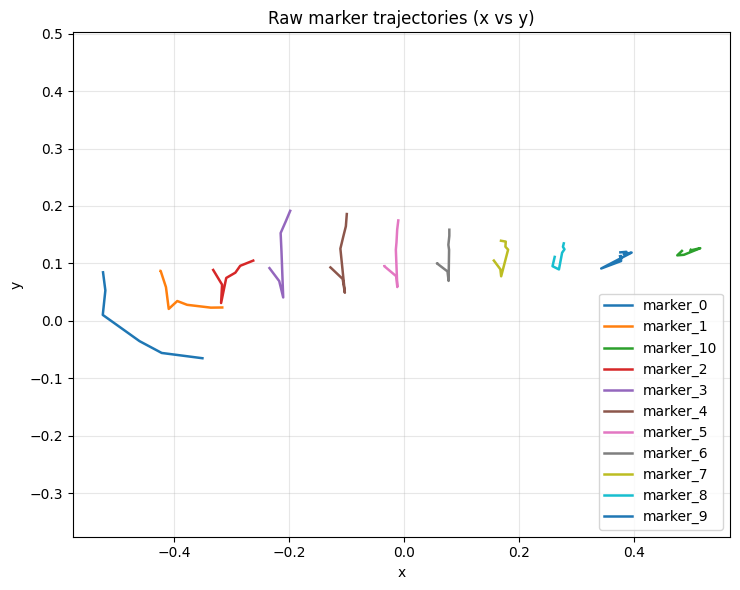

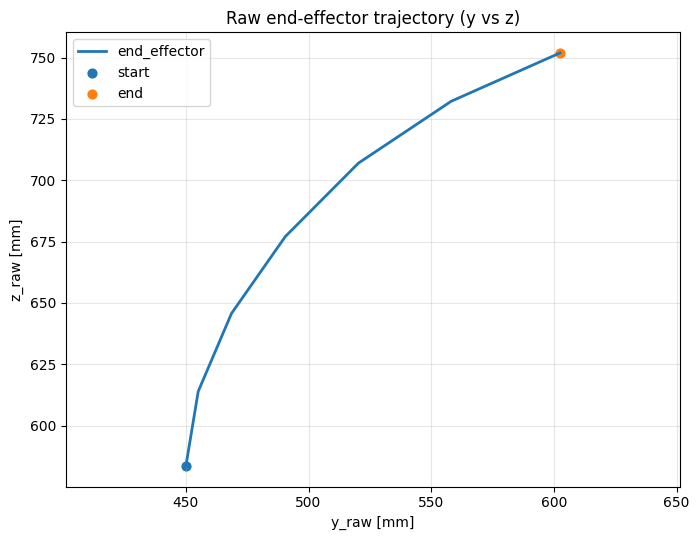

Origin from fixed marker mean:
x0 = 0.4924000958175905
y0 = 0.12112490586234854
z0 = 0.8182772360812608


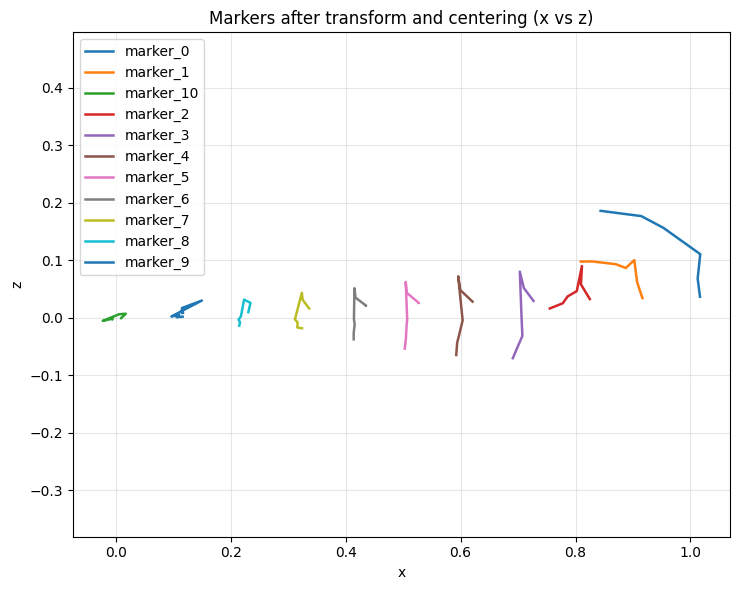

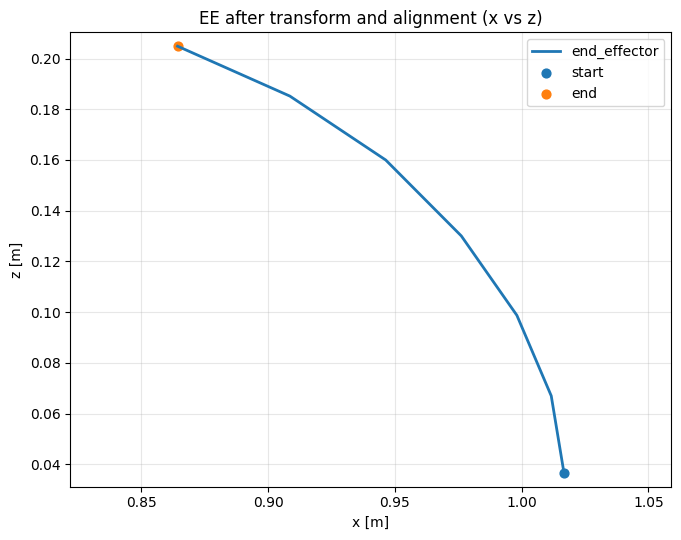

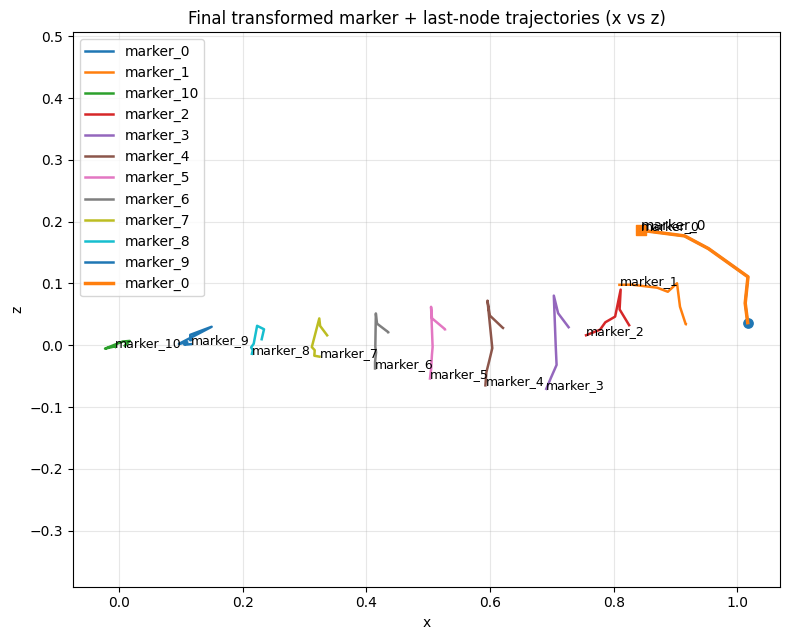

Removing NaNs: kept 6/8 timesteps
target_n_nodes: 11
use_ee_as_last_node: False
prepend_clamped_node_flag: False
append_right_ghost_clamp_flag: False
prescribe_last_two_nodes_flag: True
min_marker_presence_ratio: 0.8
qs shape: (1, 6, 43)
xb shape: (1, 6, 19)
idx_b: [ 0  1  2  3  7 11 15 19 23 27 31 35 39 40 41 42 36 37 38]
lambdas shape: (1, 6)


In [3]:
from extract_data import extract_directbc_dataset, plot_qs_snapshots
qs, xb, idx_b, lambdas = extract_directbc_dataset(input_json_path=file_path, output_npz_path=output_path, reverse_trajectory=False, make_plots=True, drop_first_points=drop_first_points, n_nodes=n_nodes, use_ee_as_last_node=False, prepend_clamped_node_flag=False, append_right_ghost_clamp_flag=False, min_marker_presence_ratio=min_marker_presence_ratio, prescribe_last_two_nodes_flag=True)

In [4]:
print(qs[0,0,:])

[0.         0.         0.         0.         0.11674264 0.
 0.00855013 0.         0.23050941 0.         0.00980457 0.
 0.33639592 0.         0.01616031 0.         0.43547498 0.
 0.02099488 0.         0.52708974 0.         0.02588511 0.
 0.62082023 0.         0.02809747 0.         0.72696352 0.
 0.02928839 0.         0.82491985 0.         0.03251809 0.
 0.91658707 0.         0.03414119 0.         1.01667822 0.
 0.03662342]


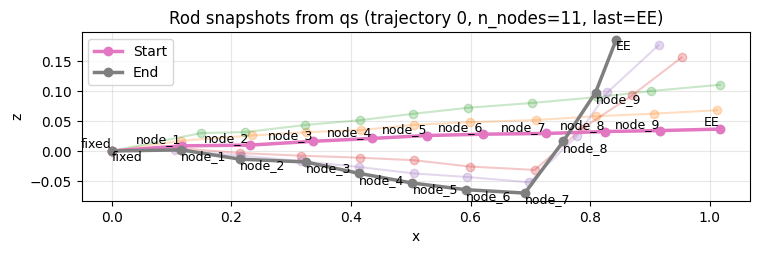

In [5]:
plot_qs_snapshots(qs, every_step=1)

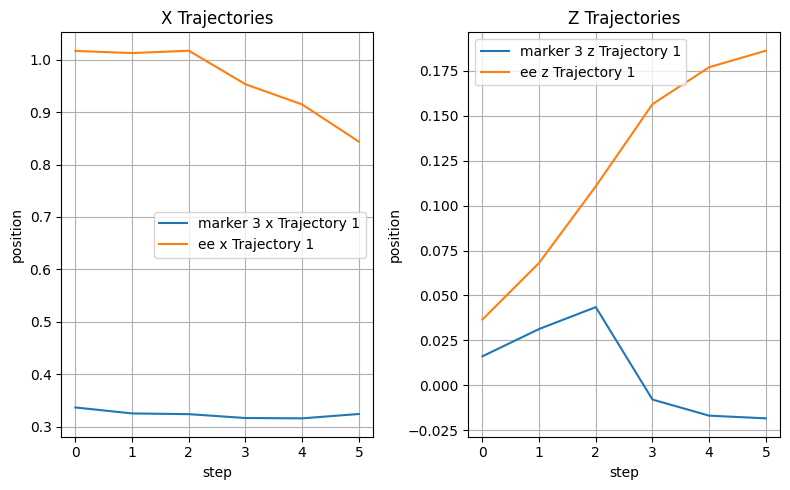

In [6]:
import matplotlib.pyplot as plt
# plot end effector and center marker trajectories for x and z directions

for i in range(qs.shape[0]):
    # separate sublots for x trajectories and z trajectories
    plt.figure(figsize=(8, 5))
    # plot x trajectories
    plt.subplot(1, 2, 1)
    plt.plot(qs[i, :, 12], label=f"marker 3 x Trajectory {i+1}")
    plt.plot(qs[i, :, -3], label=f"ee x Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("X Trajectories")
    plt.legend()
    plt.grid()

    # plot z trajectories
    plt.subplot(1, 2, 2)
    plt.plot(qs[i, :, 14], label=f"marker 3 z Trajectory {i+1}")
    plt.plot(qs[i, :, -1], label=f"ee z Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("Z Trajectories")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

In [7]:
# interpolate data to have smooth transition to snap
from interpolate_data import add_interpolated_regions

print(f"Interpolating between points {interp_range[0]} and {interp_range[1]} with {num_interp_points} interpolated points in between.")

augmented = add_interpolated_regions(
    output_path ,
    [
        {"traj_idx": 0, "timesteps": interp_range, "num_interp_points": num_interp_points},
    ],
    output_npz_path=f"tape_data/11_noded/n11_traj{traj}_tape_dataset_interp_{num_interp_points + expected_points}.npz",
)


Interpolating between points 2 and 3 with 4 interpolated points in between.


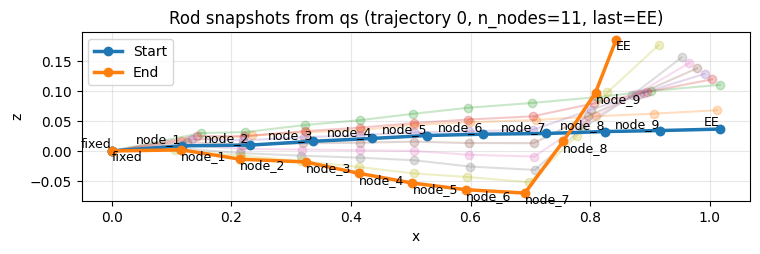

(1, 10, 43)


In [8]:
plot_qs_snapshots(augmented["qs"], every_step=1)
print(augmented["qs"].shape)

In [9]:
# print the first and last node position at t=0
print("First node position at t=0:", augmented["qs"][0, 0, :3])
print("Last node position at t=0:", augmented["qs"][0, 0, -3:])

First node position at t=0: [0. 0. 0.]
Last node position at t=0: [1.01667822 0.         0.03662342]
